In [1]:
import pandas as pd

df = pd.read_csv("/data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4424, 1)


,"Marital status;Application mode;Application order;Course;""Daytime/evening attendance\t"";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unemployment rate;Inflation rate;GDP;Target"
0,1;17;5;171;1;1;122.0;1;19;12;5;9;127.3;1;0;0;1...
1,1;15;1;9254;1;1;160.0;1;1;3;3;3;142.5;1;0;0;0;...
2,1;1;5;9070;1;1;122.0;1;37;37;9;9;124.8;1;0;0;0...
3,1;17;2;9773;1;1;122.0;1;38;37;5;3;119.6;1;0;0;...
4,2;39;1;8014;0;1;100.0;1;37;38;9;9;141.5;0;0;0;...


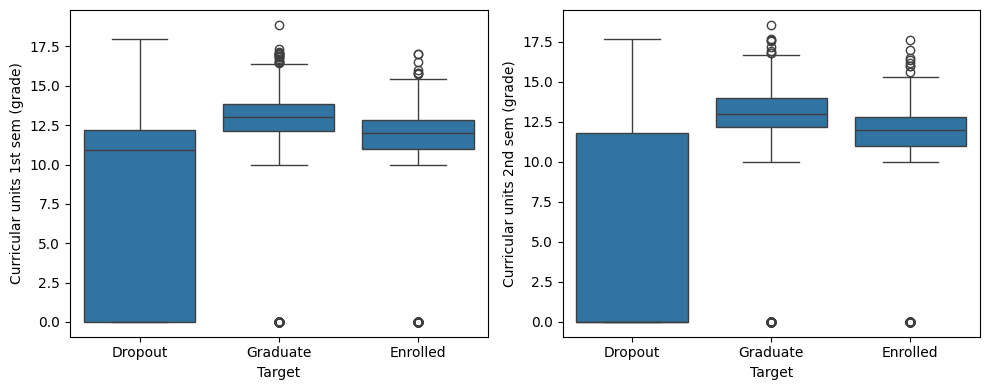

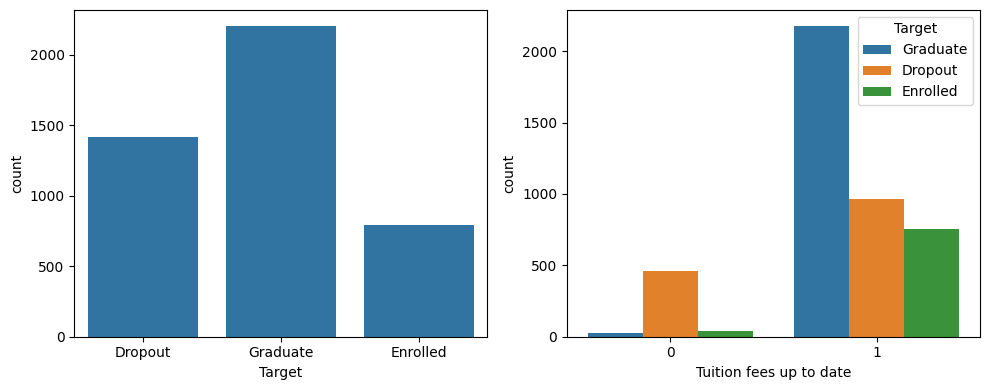

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/data.csv', sep=';')
df.columns = df.columns.str.strip()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df)

plt.subplot(1, 2, 2)
sns.boxplot(x='Target', y='Curricular units 2nd sem (grade)', data=df)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Target', data=df)

plt.subplot(1, 2, 2)
sns.countplot(x='Tuition fees up to date', hue='Target', data=df)

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/data.csv', sep=';')
df.columns = df.columns.str.strip()

df['Target'] = df['Target'].map({'Dropout': 1, 'Enrolled': 0, 'Graduate': 0})
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape:", X_test_scaled.shape)

Training Shape: (3539, 36)
Testing Shape: (885, 36)


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model Training Complete.")

Model Training Complete.


In [5]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

print("Class Predictions (First 10):")
print(y_pred[:10])

print("\nPrediction Probabilities [P(Class 0), P(Class 1)] (First 5):")
print(y_prob[:5])

Class Predictions (First 10):
[0 0 1 0 1 0 1 1 0 1]

Prediction Probabilities [P(Class 0), P(Class 1)] (First 5):
[[0.97765291 0.02234709]
 [0.7483755  0.2516245 ]
 [0.02760728 0.97239272]
 [0.97685483 0.02314517]
 [0.0541236  0.9458764 ]]


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Probability for class 1 (Dropout) extract karna
y_prob_positive = y_prob[:, 1] if y_prob.ndim == 2 else y_prob

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob_positive)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

Accuracy:  0.8859
Precision: 0.8894
Recall:    0.7359
F1-Score:  0.8054
ROC-AUC:   0.9266


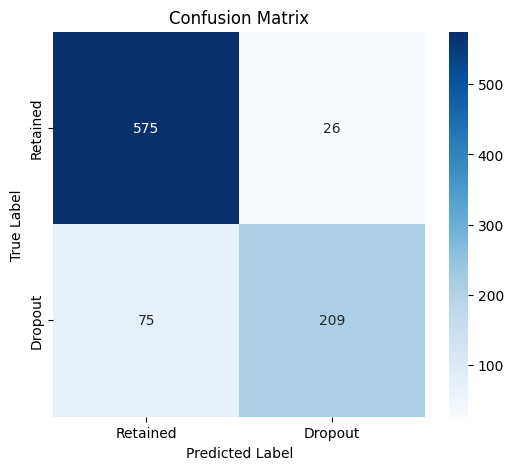

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained', 'Dropout'], yticklabels=['Retained', 'Dropout'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [9]:
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Dropout (1)']))

              precision    recall  f1-score   support

Retained (0)       0.88      0.96      0.92       601
 Dropout (1)       0.89      0.74      0.81       284

    accuracy                           0.89       885
   macro avg       0.89      0.85      0.86       885
weighted avg       0.89      0.89      0.88       885



In [11]:
import pandas as pd
import numpy as np

def predict_student_risk(student_data):
    student_df = pd.DataFrame([student_data])
    student_df = student_df.reindex(columns=X.columns, fill_value=0)
    student_scaled = scaler.transform(student_df)

    prob = model.predict_proba(student_scaled)[0][1]

    if prob >= 0.70:
        risk_level = "High Risk"
    elif prob >= 0.35:
        risk_level = "Medium Risk"
    else:
        risk_level = "Low Risk"

    return prob, risk_level

In [12]:
test_cases = [
    {
        "Profile": "High Risk Student",
        "data": {'Tuition fees up to date': 0, 'Scholarship holder': 0, 'Curricular units 1st sem (grade)': 5.0, 'Curricular units 2nd sem (grade)': 4.0, 'Age at enrollment': 28}
    },
    {
        "Profile": "Low Risk Student",
        "data": {'Tuition fees up to date': 1, 'Scholarship holder': 1, 'Curricular units 1st sem (grade)': 15.0, 'Curricular units 2nd sem (grade)': 16.0, 'Age at enrollment': 19}
    },
    {
        "Profile": "Medium Risk Student",
        "data": {'Tuition fees up to date': 0, 'Scholarship holder': 0, 'Curricular units 1st sem (grade)': 11.0, 'Curricular units 2nd sem (grade)': 10.5, 'Age at enrollment': 21}
    }
]

for tc in test_cases:
    prob, risk = predict_student_risk(tc["data"])
    print(f"--- {tc['Profile']} ---")
    print(f"Dropout Probability: {prob * 100:.2f}%")
    print(f"Assigned Risk Level: {risk}\n")

--- High Risk Student ---
Dropout Probability: 71.64%
Assigned Risk Level: High Risk

--- Low Risk Student ---
Dropout Probability: 7.93%
Assigned Risk Level: Low Risk

--- Medium Risk Student ---
Dropout Probability: 64.13%
Assigned Risk Level: Medium Risk

